In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/mdcollab/covidclinicaldata/refs/heads/master/data/04-07_carbonhealth_and_braidhealth.csv"

df = pd.read_csv(url)

In [3]:
df

,batch_date,test_name,swab_type,covid19_test_results,age,high_risk_exposure_occupation,high_risk_interactions,diabetes,chd,htn,...,loss_of_smell,loss_of_taste,runny_nose,muscle_sore,sore_throat,cxr_findings,cxr_impression,cxr_label,cxr_link,er_referral
0,2020-04-07,SARS COV 2 RNA RTPCR,Nasopharyngeal,Negative,58,True,NaN,False,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,False
1,2020-04-07,"SARS-CoV-2, NAA",Oropharyngeal,Negative,35,False,NaN,False,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,False
2,2020-04-07,SARS CoV w/CoV 2 RNA,Oropharyngeal,Negative,12,NaN,NaN,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,2020-04-07,SARS COV 2 RNA RTPCR,Nasopharyngeal,Negative,46,True,True,False,False,False,...,False,False,False,False,True,NaN,NaN,NaN,NaN,False
4,2020-04-07,SARS CoV w/CoV 2 RNA,Nasopharyngeal,Negative,-1,False,NaN,False,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,2020-04-07,"SARS-CoV-2, NAA",Nasopharyngeal,Negative,53,True,True,True,False,True,...,False,False,False,False,False,The cardiac silhouette is normal.\nThere is no...,Left basilar atelectasis or scarring,Negative,https://braid.health/viewer/study/3c22a8140ed3...,False
731,2020-04-07,SARS COV 2 RNA RTPCR,Oropharyngeal,Negative,46,False,NaN,False,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,False
732,2020-04-07,"SARS-CoV-2, NAA",Nasopharyngeal,Negative,33,False,NaN,False,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,False
733,2020-04-07,SARS CoV w/CoV 2 RNA,Oropharyngeal,Negative,53,False,True,False,True,False,...,False,False,True,True,True,The lungs are clear. The heart size is top nor...,No acute pulmonary abnormality. Please note th...,Negative,https://braid.health/viewer/study/667f0466c70b...,False


In [4]:
df.columns

Index(['batch_date', 'test_name', 'swab_type', 'covid19_test_results', 'age',
       'high_risk_exposure_occupation', 'high_risk_interactions', 'diabetes',
       'chd', 'htn', 'cancer', 'asthma', 'copd', 'autoimmune_dis', 'smoker',
       'temperature', 'pulse', 'sys', 'dia', 'rr', 'sats', 'rapid_flu_results',
       'rapid_strep_results', 'ctab', 'labored_respiration', 'rhonchi',
       'wheezes', 'days_since_symptom_onset', 'cough', 'cough_severity',
       'fever', 'sob', 'sob_severity', 'diarrhea', 'fatigue', 'headache',
       'loss_of_smell', 'loss_of_taste', 'runny_nose', 'muscle_sore',
       'sore_throat', 'cxr_findings', 'cxr_impression', 'cxr_label',
       'cxr_link', 'er_referral'],
      dtype='object')


===== Classification Report =====
              precision    recall  f1-score   support

           0       0.96      0.78      0.86       138
           1       0.11      0.44      0.18         9

    accuracy                           0.76       147
   macro avg       0.53      0.61      0.52       147
weighted avg       0.90      0.76      0.81       147


===== Confusion Matrix =====
[[107  31]
 [  5   4]]

===== ROC-AUC =====
0.6505636070853461

===== Top Feature Importances =====
                     feature  importance
0   days_since_symptom_onset    0.246554
6                fever_False    0.069473
11     sob_severity_Moderate    0.068480
1                cough_False    0.060009
9                   sob_True    0.058909
2                 cough_True    0.058098
8                  sob_False    0.057270
7                 fever_True    0.051963
4    cough_severity_Moderate    0.043834
10         sob_severity_Mild    0.042244
3        cough_severity_Mild    0.034194
5      cough_sev

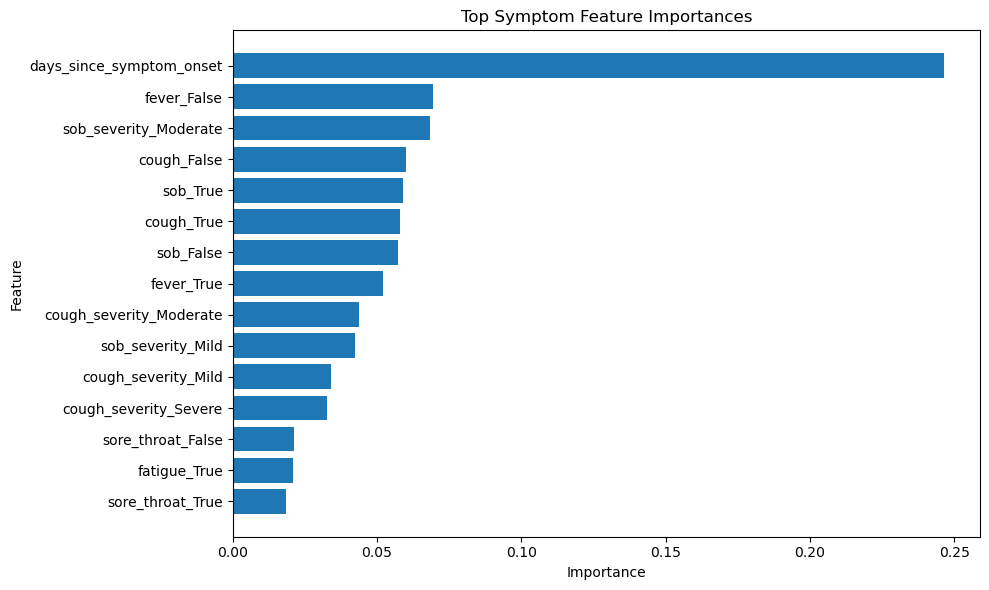

In [6]:
# ============================================
# Random Forest Model for COVID-19 Prediction
# Using ONLY symptom features
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier

# =========================================================
# LOAD DATA
# =========================================================
# Replace with your actual dataset path

df = pd.read_csv("https://raw.githubusercontent.com/mdcollab/covidclinicaldata/refs/heads/master/data/04-07_carbonhealth_and_braidhealth.csv")

# =========================================================
# SELECT ONLY SYMPTOM FEATURES
# =========================================================

symptom_features = [

    'days_since_symptom_onset',

    'cough',
    'cough_severity',

    'fever',

    'sob',
    'sob_severity',

    'diarrhea',
    'fatigue',
    'headache',

    'loss_of_smell',
    'loss_of_taste',

    'runny_nose',
    'muscle_sore',
    'sore_throat'
]

target_col = "covid19_test_results"

# =========================================================
# KEEP ONLY NEEDED COLUMNS
# =========================================================

df = df[symptom_features + [target_col]].copy()

# =========================================================
# CLEAN TARGET VARIABLE
# =========================================================

df[target_col] = (
    df[target_col]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Keep only positive/negative rows
df = df[df[target_col].isin(["positive", "negative"])]

# Convert target to binary
df[target_col] = df[target_col].map({
    "positive": 1,
    "negative": 0
})

# =========================================================
# SPLIT FEATURES / TARGET
# =========================================================

X = df[symptom_features]
y = df[target_col]

# =========================================================
# IDENTIFY COLUMN TYPES
# =========================================================

numeric_features = [
    'days_since_symptom_onset'
]

categorical_features = [
    col for col in symptom_features
    if col not in numeric_features
]

# =========================================================
# PREPROCESSING
# =========================================================

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# =========================================================
# RANDOM FOREST MODEL
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

# =========================================================
# BUILD PIPELINE
# =========================================================

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf_model)
])

# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# =========================================================
# TRAIN MODEL
# =========================================================

model.fit(X_train, y_train)

# =========================================================
# PREDICTIONS
# =========================================================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# =========================================================
# EVALUATION
# =========================================================

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))

print("\n===== Confusion Matrix =====")
print(confusion_matrix(y_test, y_pred))

print("\n===== ROC-AUC =====")
print(roc_auc_score(y_test, y_prob))

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

# Extract one-hot encoded feature names
ohe = model.named_steps["preprocessor"] \
           .named_transformers_["cat"] \
           .named_steps["onehot"]

encoded_cat_features = ohe.get_feature_names_out(categorical_features)

all_features = (
    numeric_features +
    list(encoded_cat_features)
)

# Get importances
importances = model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_features,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n===== Top Feature Importances =====")
print(feature_importance_df.head(20))

# =========================================================
# OPTIONAL: PLOT FEATURE IMPORTANCE
# =========================================================

import matplotlib.pyplot as plt

top_n = 15

top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Symptom Feature Importances")
plt.tight_layout()

plt.show()